# Neural Network (NN3) on the MALL Extended 5-min Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the `NN3` neural network from Christensen et al. (2023) on the MALL Extended 5-min feature set for the EURO STOXX 50 index over the period 1999--2020.

This implementation follows the neural-network design in the paper as closely as is practical in this thesis setup:

- final MALL extended predictors:
  - `RVD`, `RVW`, `RVM`
  - `VSTOXX`
  - `CISS`
  - `logEPU_1m_lag`
  - `EURUSD_ret`
  - `BRENT_ret`
  - `NIKKEI_ret`, `NIKKEI_sq`
  - `SP500_ret_lag`, `SP500_sq_lag`
  - `M1W`, `M1M`
  - `EURIBOR_OIS_CS`, `TERM_CS`
- three hidden layers with `8`, `4`, and `2` neurons (`NN3` in the paper)
- Leaky ReLU activation with slope `0.01`
- Adam optimizer with learning rate `0.001`
- maximum `500` epochs and early stopping patience `100`
- Glorot (Xavier) normal initialization
- dropout retain probability `0.8` during training
- `100` independent seed initializations ranked by validation MSE
- forecasts from:
  - the single best network (`ensemble size = 1`)
  - the average of the top `10` networks (`ensemble size = 10`)

The neural network is estimated on a fixed train / validation / test split, which is also the approach used for neural networks in the reference paper due to computational cost. Both predictors and the target variable are standardized using training-sample moments before estimation, and forecasts are back-transformed to the original realized-variance scale for evaluation.


## 1. Loading Data
Loading in data from the `MALL_extended_5min.csv` file.


In [4]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load MALL extended dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_extended_5min.csv"
MALL = pd.read_csv(file_path, index_col="Date", parse_dates=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()


Using device: cpu
Shape: (5489, 39)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,EURIBOR_3M,EURIBOR_3M_diff,EURO_10Y_SWAP,EURO_10Y_SWAP_diff,EURO_3M_OVERNIGHT_INDEX,EURO_3M_OVERNIGHT_INDEX_diff,EURIBOR_OIS_CS,TERM_CS,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,0.000000,...,3.222,-0.012,4.160,-0.005,3.115,0.035,0.107,0.938,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,0.000000,...,3.214,-0.008,4.162,0.002,3.100,-0.015,0.114,0.948,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,0.000000,...,3.206,-0.008,4.160,-0.002,3.090,-0.010,0.116,0.954,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,0.000000,...,3.196,-0.010,4.130,-0.030,3.095,0.005,0.101,0.934,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.001398,...,3.193,-0.003,4.225,0.095,3.090,-0.005,0.103,1.032,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)


Following Christensen et al. (2023), the sample is split chronologically into a training set (70%), validation set (10%), and test set (20%). The temporal ordering is strictly preserved to avoid look-ahead bias. For the neural network, this split remains fixed throughout the out-of-sample evaluation.


In [8]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val = int(np.floor(0.10 * n))
n_test = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx = MALL.index[n_train:n_train + n_val]
test_idx = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. MALL Extended Feature Set Construction and Standardization

The `NN3` network is estimated on the final MALL extended feature set, consisting of the MHAR realized-volatility block augmented by macro-financial, cross-market, and euro-area spread predictors. In line with the paper, the explanatory variables are standardized using training-sample moments. To improve numerical stability in neural-network estimation, the target variable is also standardized using the same training window and later back-transformed for forecast evaluation.


In [11]:
# Define target and final MALL extended feature set
feature_cols = [
    "RVD", "RVW", "RVM",
    "VSTOXX", "CISS", "logEPU_1m_lag",
    "EURUSD_ret", "BRENT_ret",
    "NIKKEI_ret", "NIKKEI_sq",
    "SP500_ret_lag", "SP500_sq_lag",
    "M1W", "M1M",
    "EURIBOR_OIS_CS", "TERM_CS"
]

y = MALL["RV_target"].values
X_MALL = MALL[feature_cols].values

# Raw splits
X_train = X_MALL[:n_train]
X_val = X_MALL[n_train:n_train + n_val]
X_test = X_MALL[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Feature scaling using training moments only
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0, ddof=0)
X_std = np.where(X_std == 0, 1.0, X_std)

X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

# Target scaling using training moments only
y_mean = y_train.mean()
y_std = y_train.std(ddof=0)
if y_std == 0:
    y_std = 1.0

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print("Feature set:")
for col in feature_cols:
    print(f"  - {col}")

print(f"\nTraining set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nPredictor standardization check:")
print(f"  Means (first 5): {X_train_scaled.mean(axis=0)[:5].round(6)}")
print(f"  Std   (first 5): {X_train_scaled.std(axis=0)[:5].round(6)}")
print("\nTarget standardization check:")
print(f"  Train mean (scaled): {y_train_scaled.mean():.6f}")
print(f"  Train std  (scaled): {y_train_scaled.std():.6f}")
print(f"  Raw target mean:     {y_mean:.6e}")
print(f"  Raw target std:      {y_std:.6e}")


Feature set:
  - RVD
  - RVW
  - RVM
  - VSTOXX
  - CISS
  - logEPU_1m_lag
  - EURUSD_ret
  - BRENT_ret
  - NIKKEI_ret
  - NIKKEI_sq
  - SP500_ret_lag
  - SP500_sq_lag
  - M1W
  - M1M
  - EURIBOR_OIS_CS
  - TERM_CS

Training set:   X=(3842, 16), y=(3842,)
Validation set: X=(548, 16), y=(548,)
Test set:       X=(1099, 16), y=(1099,)

Predictor standardization check:
  Means (first 5): [ 0. -0. -0. -0.  0.]
  Std   (first 5): [1. 1. 1. 1. 1.]

Target standardization check:
  Train mean (scaled): 0.000000
  Train std  (scaled): 1.000000
  Raw target mean:     1.608657e-04
  Raw target std:      2.992674e-04


## 4. Define the NN3 Architecture

Following the paper, `NN3` is the third neural network in the geometric pyramid family. It contains three hidden layers with `8`, `4`, and `2` neurons. We use Leaky ReLU with slope `0.01` and Glorot normal initialization. The paper reports dropout `0.8`; here this is implemented as a retain probability of `0.8`, corresponding to a PyTorch dropout probability of `0.2` during training.


In [14]:
class NN3(nn.Module):
    def __init__(self, input_dim, hidden_dims=(8, 4, 2), keep_prob=0.8):
        super().__init__()
        self.hidden1 = nn.Linear(input_dim, hidden_dims[0])
        self.hidden2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.hidden3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.activation = nn.LeakyReLU(negative_slope=0.01)
        self.dropout = nn.Dropout(p=1.0 - keep_prob)
        self.output = nn.Linear(hidden_dims[2], 1)
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in [self.hidden1, self.hidden2, self.hidden3, self.output]:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.hidden1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.hidden2(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.hidden3(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x.squeeze(-1)

input_dim = X_train_scaled.shape[1]
model_test = NN3(input_dim=input_dim).to(device)

print(model_test)
print(f"\nInput dimension:   {input_dim}")
print("Hidden neurons:    8, 4, 2")
print("Output dimension:  1")
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters())}")


NN3(
  (hidden1): Linear(in_features=16, out_features=8, bias=True)
  (hidden2): Linear(in_features=8, out_features=4, bias=True)
  (hidden3): Linear(in_features=4, out_features=2, bias=True)
  (activation): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.19999999999999996, inplace=False)
  (output): Linear(in_features=2, out_features=1, bias=True)
)

Input dimension:   16
Hidden neurons:    8, 4, 2
Output dimension:  1

Total parameters: 185


## 5. Training Function with Early Stopping

The network is trained by minimizing mean squared error in standardized target space using Adam with learning rate `0.001`. Each epoch consists of mini-batch updates with batch size `64`, where the training indices are reshuffled every epoch. Training runs for at most `500` epochs. After each epoch the validation loss is evaluated on the full validation set; early stopping is activated if it does not improve for `100` consecutive epochs, after which the best validation-state parameters are restored.

In [17]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)


def train_nn3(X_tr, y_tr, X_vl, y_vl,
              input_dim,
              hidden_dims=(8, 4, 2),
              keep_prob=0.8,
              learning_rate=0.001,
              max_epochs=500,
              patience=100,
              batch_size=64,
              seed=0):

    set_seed(seed)

    X_tr_t = to_tensor(X_tr)
    y_tr_t = to_tensor(y_tr)
    X_vl_t = to_tensor(X_vl)
    y_vl_t = to_tensor(y_vl)

    model = NN3(input_dim=input_dim, hidden_dims=hidden_dims, keep_prob=keep_prob).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    n_train_obs = X_tr_t.shape[0]

    best_val_loss = np.inf
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # Mini-batch Adam: shuffle training indices each epoch
        model.train()
        perm = torch.randperm(n_train_obs, device=device)
        for start in range(0, n_train_obs, batch_size):
            idx = perm[start:start + batch_size]
            optimizer.zero_grad()
            pred_b = model(X_tr_t[idx])
            loss_b = criterion(pred_b, y_tr_t[idx])
            loss_b.backward()
            optimizer.step()

        # Evaluate validation loss once per epoch (after all mini-batches)
        model.eval()
        with torch.no_grad():
            pred_vl = model(X_vl_t)
            loss_vl = criterion(pred_vl, y_vl_t).item()

        if loss_vl < best_val_loss:
            best_val_loss = loss_vl
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    return model, best_val_loss, best_epoch


## 6. Initial Validation Check

Before estimating the large seed ensemble, we train a single network on the initial training / validation split as a sanity check. The validation loss is reported in standardized target space, while predictions are back-transformed to the original realized-variance scale for interpretation.


In [20]:
model_check, val_loss_check, best_epoch_check = train_nn3(
    X_tr=X_train_scaled,
    y_tr=y_train_scaled,
    X_vl=X_val_scaled,
    y_vl=y_val_scaled,
    input_dim=input_dim,
    seed=0
)

with torch.no_grad():
    preds_check_scaled = model_check(to_tensor(X_val_scaled)).detach().cpu().numpy()
preds_check = preds_check_scaled * y_std + y_mean

print(f"Validation MSE (scaled, seed=0): {val_loss_check:.6e}")
print(f"Best epoch:                      {best_epoch_check}")
print(f"Mean validation forecast:       {preds_check.mean():.6e}")
print(f"Mean actual validation RV:      {y_val.mean():.6e}")
print(f"Any negative forecasts:         {(preds_check < 0).sum()}")
print(f"Any NaN forecasts:              {np.isnan(preds_check).sum()}")


Validation MSE (scaled, seed=0): 1.064825e-01
Best epoch:                      119
Mean validation forecast:       1.198090e-04
Mean actual validation RV:      1.221296e-04
Any negative forecasts:         0
Any NaN forecasts:              0


## 7. Ensemble Training on the Fixed Estimation Window

Following the paper's seed-ranking idea, we train `100` independent versions of the same `NN3` architecture with different random seeds. The networks are ranked by validation MSE in standardized target space. We then retain:

- the single best network (`ensemble size = 1`)
- the top `10` networks (`ensemble size = 10`)


In [22]:
N_SEEDS = 100
TOP_K = 10

seed_records = []
start_time = time.time()

print(f"Training {N_SEEDS} independent NN3 networks...")
for seed in range(N_SEEDS):
    model_i, val_loss_i, best_epoch_i = train_nn3(
        X_tr=X_train_scaled,
        y_tr=y_train_scaled,
        X_vl=X_val_scaled,
        y_vl=y_val_scaled,
        input_dim=input_dim,
        seed=seed
    )
    seed_records.append({
        "seed": seed,
        "val_loss": val_loss_i,
        "best_epoch": best_epoch_i,
        "model": model_i
    })

    if (seed + 1) % 25 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Completed {seed + 1:3d}/{N_SEEDS} seeds | Elapsed: {elapsed:.2f} min")

elapsed = (time.time() - start_time) / 60
print(f"\nTraining time: {elapsed:.2f} minutes")

# Rank by validation loss
seed_records.sort(key=lambda x: x["val_loss"])
best_network = seed_records[0]
top10_networks = seed_records[:TOP_K]

ranking_df = pd.DataFrame([
    {
        "rank": i + 1,
        "seed": rec["seed"],
        "val_mse_scaled": rec["val_loss"],
        "best_epoch": rec["best_epoch"]
    }
    for i, rec in enumerate(seed_records)
])

print("\nTop seeds by validation MSE:")
display(ranking_df.head(10))


Training 100 independent NN3 networks...
  Completed  25/100 seeds | Elapsed: 1.36 min
  Completed  50/100 seeds | Elapsed: 2.89 min
  Completed  75/100 seeds | Elapsed: 4.25 min
  Completed 100/100 seeds | Elapsed: 5.82 min

Training time: 5.82 minutes

Top seeds by validation MSE:


,rank,seed,val_mse_scaled,best_epoch
0,1,2,0.098059,179
1,2,81,0.098332,370
2,3,20,0.098619,440
3,4,76,0.098705,133
4,5,23,0.098947,196
5,6,38,0.099531,92
6,7,54,0.100102,148
7,8,31,0.100153,188
8,9,40,0.100346,79
9,10,21,0.100658,147


## 8. One-Day-Ahead Test Forecasts

The selected `NN3` networks are now used to forecast the entire test set. The forecasts are first produced in standardized target space and then back-transformed to the original realized-variance scale. If any forecast is negative, it is replaced by the minimum realized variance observed in the pre-test sample (training plus validation), which acts as the non-negativity safeguard used elsewhere in the thesis.


In [26]:
X_test_t = to_tensor(X_test_scaled)
min_rv_insample = y[:n_train + n_val].min()

# Best network forecast
best_network["model"].eval()
with torch.no_grad():
    pred_best_scaled = best_network["model"](X_test_t).detach().cpu().numpy()
pred_best = pred_best_scaled * y_std + y_mean
pred_best = np.maximum(pred_best, min_rv_insample)

# Top-10 ensemble forecast
pred_top10_all = []
for rec in top10_networks:
    rec["model"].eval()
    with torch.no_grad():
        pred_i_scaled = rec["model"](X_test_t).detach().cpu().numpy()
        pred_i = pred_i_scaled * y_std + y_mean
        pred_top10_all.append(pred_i)

pred_top10 = np.mean(pred_top10_all, axis=0)
pred_top10 = np.maximum(pred_top10, min_rv_insample)

results_NN3 = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast_best": pred_best,
    "RV_forecast_top10": pred_top10
}, index=test_idx)

errors_best = results_NN3["RV_actual"] - results_NN3["RV_forecast_best"]
errors_top10 = results_NN3["RV_actual"] - results_NN3["RV_forecast_top10"]

mse_best = np.mean(errors_best ** 2)
mse_top10 = np.mean(errors_top10 ** 2)

print(f"Forecast period: {test_idx[0].date()} to {test_idx[-1].date()}")
print(f"In-sample floor: {min_rv_insample:.6e}")
print(f"\nNN3_best MSE: {mse_best:.6e}")
print(f"NN3_top10 MSE: {mse_top10:.6e}")


Forecast period: 2016-04-21 to 2020-08-06
In-sample floor: 3.910328e-08

NN3_best MSE: 5.232045e-08
NN3_top10 MSE: 5.340869e-08


## 9. Save Forecasts and Summary Statistics


In [29]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL Extended/Neural Networks"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL Extended/Neural Networks"

os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

results_NN3.to_csv(os.path.join(forecast_path, "forecasts_NN3.csv"))
mse_summary_NN3 = pd.DataFrame({
    "Model": ["NN3_best", "NN3_top10"],
    "MSE": [mse_best, mse_top10],
    "RMSE": [np.sqrt(mse_best), np.sqrt(mse_top10)],
    "MAE": [errors_best.abs().mean(), errors_top10.abs().mean()],
    "Mean_Error": [errors_best.mean(), errors_top10.mean()]
}).set_index("Model")

mse_summary_NN3.to_csv(os.path.join(mse_path, "mse_summary_NN3.csv"))

print(f"Forecasts saved to:   {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_NN3)}")
print()
print(mse_summary_NN3.to_string())


Forecasts saved to:   /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL Extended/Neural Networks
MSE summary saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL Extended/Neural Networks
Rows saved: 1099

                    MSE      RMSE       MAE  Mean_Error
Model                                                  
NN3_best   5.232045e-08  0.000229  0.000055   -0.000014
NN3_top10  5.340869e-08  0.000231  0.000060   -0.000017


## 10. Results
### 10.1 Forecast Visualization


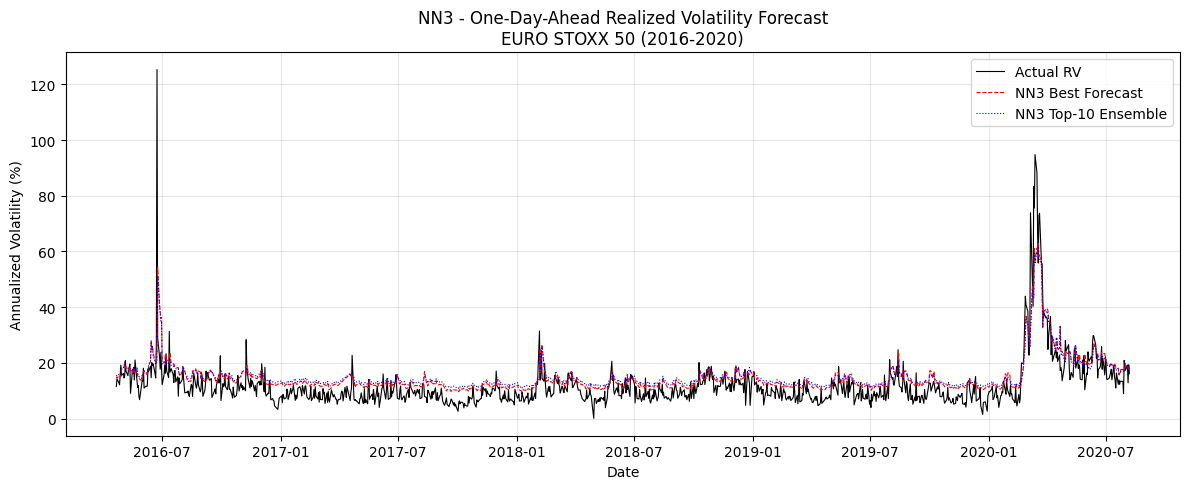


Summary of forecast errors:

NN3 Best:
  Mean error:  -1.357477e-05
  RMSE:        2.287366e-04
  MAE:         5.497239e-05

NN3 Top-10 Ensemble:
  Mean error:  -1.746151e-05
  RMSE:        2.311032e-04
  MAE:         5.960893e-05


In [32]:
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_NN3["RV_actual"] * 252) * 100,
    "Forecast_best": np.sqrt(results_NN3["RV_forecast_best"] * 252) * 100,
    "Forecast_top10": np.sqrt(results_NN3["RV_forecast_top10"] * 252) * 100
}, index=results_NN3.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast_best"], label="NN3 Best Forecast", color="red", linewidth=0.8, linestyle="--")
ax.plot(results_plot["Forecast_top10"], label="NN3 Top-10 Ensemble", color="blue", linewidth=0.8, linestyle=":")
ax.set_title("NN3 - One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016-2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary of forecast errors:")
print("\nNN3 Best:")
print(f"  Mean error:  {errors_best.mean():.6e}")
print(f"  RMSE:        {np.sqrt(mse_best):.6e}")
print(f"  MAE:         {errors_best.abs().mean():.6e}")

print("\nNN3 Top-10 Ensemble:")
print(f"  Mean error:  {errors_top10.mean():.6e}")
print(f"  RMSE:        {np.sqrt(mse_top10):.6e}")
print(f"  MAE:         {errors_top10.abs().mean():.6e}")
